# Quantium Retail Strategy & Analytics – Task 2

## Trial Store Analysis and Uplift Testing

The objective of this task is to assess whether the new store layout trial had a measurable impact on chip category performance.

The trial was conducted in stores 77, 86 and 88.  
To assess performance, each trial store will be compared against a similar control store based on pre-trial store behaviour.

The analysis focuses on:

- monthly total sales revenue
- monthly number of customers
- monthly transactions per customer
- selecting suitable control stores
- comparing trial and control performance during the trial period
- identifying whether the trial should be rolled out more broadly

## 1. Import Libraries

The required Python libraries are imported for data manipulation, statistical analysis and visualisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

The cleaned output from Task 1 is used as the starting point for Task 2.  
This avoids repeating earlier cleaning steps and allows the analysis to focus on store-level trial performance.

In [2]:
try:
  data=pd.read_csv('/content/merged_data.csv')
  print(f'Dataset shape{data.shape}')
except Exception as e:
  print(f'Error loading the dataset: {e}')

Dataset shape(264834, 13)


## 3. Initial Data Check

Before creating store-level metrics, the dataset structure is reviewed to confirm column types, missing values and key fields required for the trial analysis.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATE              264834 non-null  object 
 1   STORE_NBR         264834 non-null  int64  
 2   LYLTY_CARD_NBR    264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
 12  MULTIPACK         264834 non-null  bool   
dtypes: bool(1), float64(1), int64(6), object(5)
memory usage: 24.5+ MB


## 4. Convert Date Column

The date column is converted into datetime format so that monthly store performance can be analysed correctly.

In [4]:
data['DATE']=pd.to_datetime(data['DATE'])

In [5]:
print(data['DATE'].dtype)

datetime64[ns]


#### Initial Observations

The dataset contains transaction-level chip purchase data across multiple stores.

Key variables relevant for the trial analysis include:
- STORE_NBR for store-level comparison
- DATE for monthly trend analysis
- TOT_SALES for revenue measurement
- TXN_ID for transaction counts
- LYLTY_CARD_NBR for customer counts

The analysis will focus on store-level performance trends over time.

## 5. Store Coverage Overview

The trial analysis is store-based, so the first step is to understand how many stores are present in the dataset and how transaction volume varies by store.

In [6]:
data['STORE_NBR'].nunique()

272

In [7]:
data['STORE_NBR'].value_counts().sort_values()

,count
STORE_NBR,
92,1
76,1
211,2
252,2
11,2
...,...
237,1785
165,1819
93,1832


#### Store Distribution Review
Transaction activity varies considerably across stores.  
Some stores contain very limited observations while others contribute substantially more transactions.

This reinforces the importance of selecting comparable control stores during the trial analysis.

## 6. Create Monthly Period Column

Task 2 requires store performance to be compared month by month.  
The transaction-level dates are therefore converted into a monthly period column.

In [8]:
#to extract month and year out of dates
data['MONTH_ID'] = data['DATE'].dt.to_period('M')

In [9]:
data['MONTH_ID'].head(5)

,MONTH_ID
0,2018-10
1,2019-05
2,2019-05
3,2018-08
4,2018-08


## 7. Create Monthly Store-Level Metrics

The transaction-level dataset is aggregated into monthly store-level metrics.

For each store and month, the analysis calculates:

- total sales revenue
- number of unique customers
- number of transactions
- transactions per customer

This monthly store-level table will be used to identify suitable control stores and assess trial performance.

In [10]:
monthly_store_metrics = data.groupby(
    ['STORE_NBR', 'MONTH_ID']
).agg(
    total_sales=('TOT_SALES', 'sum'),
    unique_customers=('LYLTY_CARD_NBR', 'nunique'),
    total_transactions=('TXN_ID', 'nunique')
).reset_index()

In [11]:
monthly_store_metrics['transactions_per_customer'] = (
    monthly_store_metrics['total_transactions'] /
    monthly_store_metrics['unique_customers']
)

In [12]:
monthly_store_metrics.head()

,STORE_NBR,MONTH_ID,total_sales,unique_customers,total_transactions,transactions_per_customer
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


#### Monthly Store-Level Metrics

The transaction-level dataset has now been aggregated into monthly store-level metrics.

Each row now represents:
- one store
- during one month
- with summarized performance indicators

This structure is required for comparing historical store behaviour and identifying suitable control stores.

## 8. Check Monthly Coverage by Store

Only stores with sales data across all months should be considered as possible control stores.  
Stores with incomplete monthly records may produce unreliable comparisons.

In [13]:
store_month_counts = monthly_store_metrics.groupby(
    'STORE_NBR'
)['MONTH_ID'].nunique().sort_values()

In [14]:
store_month_counts.head()

,MONTH_ID
STORE_NBR,
85,1
92,1
76,1
31,2
206,2


In [15]:
store_month_counts.tail()

,MONTH_ID
STORE_NBR,
21,12
20,12
19,12
18,12
17,12


In [16]:
complete_stores = store_month_counts[store_month_counts == 12].index

In [17]:
monthly_store_metrics_complete = monthly_store_metrics[
    monthly_store_metrics['STORE_NBR'].isin(complete_stores)
]

In [18]:
monthly_store_metrics_complete['STORE_NBR'].nunique()

260

#### Filtering Stores with Complete Monthly Data

Only stores with observations across all 12 months were retained for analysis.

Stores with incomplete monthly data may distort similarity comparisons and produce unreliable trial assessments.

## 9. Define Trial and Pre-Trial Periods

The trial period ran from February 2019 to April 2019.

The pre-trial period is used to identify control stores that had similar historical performance before the layout change.

In [19]:
trial_stores = [77, 86, 88]

pre_trial_data = monthly_store_metrics_complete[
    monthly_store_metrics_complete['MONTH_ID'] < '2019-02'
]

trial_period_data = monthly_store_metrics_complete[
    (monthly_store_metrics_complete['MONTH_ID'] >= '2019-02') &
    (monthly_store_metrics_complete['MONTH_ID'] <= '2019-04')
]

In [20]:
pre_trial_data.head()

,STORE_NBR,MONTH_ID,total_sales,unique_customers,total_transactions,transactions_per_customer
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


## 10. Control Store Selection Method

Control stores are selected using pre-trial performance only.

A suitable control store should have similar historical sales and customer behaviour to the trial store before the layout change.

Similarity will be assessed using:
- correlation in monthly sales trends
- correlation in monthly customer trends
- similarity in average monthly sales levels
- similarity in average monthly customer counts

In [21]:
def calculate_control_scores(trial_store, pre_trial_data, trial_stores):

    candidate_stores = pre_trial_data[
        ~pre_trial_data['STORE_NBR'].isin(trial_stores)
    ]['STORE_NBR'].unique()

    scores = []

    trial_data = pre_trial_data[
        pre_trial_data['STORE_NBR'] == trial_store
    ].sort_values('MONTH_ID').reset_index(drop=True)

    for control_store in candidate_stores:

        control_data = pre_trial_data[
            pre_trial_data['STORE_NBR'] == control_store
        ].sort_values('MONTH_ID').reset_index(drop=True)

        sales_corr = trial_data['total_sales'].corr(control_data['total_sales'])
        customer_corr = trial_data['unique_customers'].corr(control_data['unique_customers'])

        sales_diff = abs(
            trial_data['total_sales'].mean() - control_data['total_sales'].mean()
        )

        customer_diff = abs(
            trial_data['unique_customers'].mean() - control_data['unique_customers'].mean()
        )

        scores.append({
            'trial_store': trial_store,
            'control_store': control_store,
            'sales_corr': sales_corr,
            'customer_corr': customer_corr,
            'sales_diff': sales_diff,
            'customer_diff': customer_diff
        })

    scores_df = pd.DataFrame(scores)

    scores_df['sales_mag_score'] = 1 - (
        (scores_df['sales_diff'] - scores_df['sales_diff'].min()) /
        (scores_df['sales_diff'].max() - scores_df['sales_diff'].min())
    )

    scores_df['customer_mag_score'] = 1 - (
        (scores_df['customer_diff'] - scores_df['customer_diff'].min()) /
        (scores_df['customer_diff'].max() - scores_df['customer_diff'].min())
    )

    scores_df['final_score'] = (
        scores_df['sales_corr'] * 0.25 +
        scores_df['customer_corr'] * 0.25 +
        scores_df['sales_mag_score'] * 0.25 +
        scores_df['customer_mag_score'] * 0.25
    )

    return scores_df.sort_values('final_score', ascending=False)

In [22]:
#select the control
scores_77 = calculate_control_scores(77, pre_trial_data, trial_stores)
scores_86 = calculate_control_scores(86, pre_trial_data, trial_stores)
scores_88 = calculate_control_scores(88, pre_trial_data, trial_stores)

## 11. Calculate Final Similarity Score

Control stores are ranked using a combined similarity measure.

The final score considers:
*  similarity in monthly sales movement
*  similarity in customer trends
* closeness in sales magnitude
*   closeness in customer magnitude

Higher scores indicate stronger similarity to the trial store.



In [23]:
scores_77['final_score'] = (
    scores_77['sales_corr'] +
    scores_77['customer_corr'] +
    scores_77['sales_mag_score'] +
    scores_77['customer_mag_score']
) / 4

scores_77 = scores_77.sort_values(
    'final_score',
    ascending=False
)

scores_77.head(10)

,trial_store,control_store,sales_corr,customer_corr,sales_diff,customer_diff,sales_mag_score,customer_mag_score,final_score
218,77,233,0.903774,0.990358,5.600000,0.142857,0.995783,0.998469,0.972096
38,77,41,0.783232,0.844219,45.342857,0.142857,0.963195,0.998469,0.897279
15,77,17,0.842668,0.747308,155.614286,1.000000,0.872777,0.989280,0.863008
238,77,254,0.577108,0.916208,101.057143,6.142857,0.917512,0.934150,0.836245
156,77,167,0.657110,0.717913,53.485714,2.000000,0.956518,0.978560,0.827525
105,77,115,0.689159,0.718882,87.657143,2.857143,0.928499,0.969372,0.826478
78,77,84,0.684348,0.858571,219.928571,7.428571,0.820041,0.920368,0.820832
46,77,50,0.763866,0.607391,28.085714,6.285714,0.977346,0.932619,0.820305
101,77,111,0.519473,0.685926,38.428571,0.142857,0.968865,0.998469,0.793183
249,77,265,0.639759,0.573460,37.557143,1.000000,0.969579,0.989280,0.793020


In [24]:
scores_86['final_score'] = (
    scores_86['sales_corr'] +
    scores_86['customer_corr'] +
    scores_86['sales_mag_score'] +
    scores_86['customer_mag_score']
) / 4

scores_86 = scores_86.sort_values(
    'final_score',
    ascending=False
)

scores_86.head(10)

,trial_store,control_store,sales_corr,customer_corr,sales_diff,customer_diff,sales_mag_score,customer_mag_score,final_score
144,86,155,0.877882,0.942876,26.978571,0.000000,0.969415,1.000000,0.947543
99,86,109,0.788300,0.770778,16.921429,0.428571,0.981136,0.995529,0.883936
127,86,138,0.759864,0.749701,29.021429,3.000000,0.967034,0.968703,0.861326
104,86,114,0.734415,0.855339,68.757143,6.285714,0.920724,0.934426,0.861226
210,86,225,0.617533,0.733791,4.178571,0.428571,0.995987,0.995529,0.835710
207,86,222,0.795075,0.458238,20.835714,5.571429,0.976574,0.941878,0.792941
161,86,172,0.524475,0.571024,0.921429,3.285714,0.999784,0.965723,0.765251
136,86,147,0.545463,0.641090,60.657143,8.000000,0.930164,0.916542,0.758315
52,86,56,0.551441,0.703549,154.850000,15.428571,0.820386,0.839046,0.728605
71,86,75,0.706307,0.578150,263.378571,7.714286,0.693900,0.919523,0.724470


In [25]:
scores_88['final_score'] = (
    scores_88['sales_corr'] +
    scores_88['customer_corr'] +
    scores_88['sales_mag_score'] +
    scores_88['customer_mag_score']
) / 4

scores_88 = scores_88.sort_values(
    'final_score',
    ascending=False
)

scores_88.head(10)

,trial_store,control_store,sales_corr,customer_corr,sales_diff,customer_diff,sales_mag_score,customer_mag_score,final_score
222,88,237,0.308479,0.947326,2.085714,0.714286,1.000000,1.000000,0.813951
167,88,178,0.731857,0.939466,405.585714,22.142857,0.694995,0.823322,0.797410
65,88,69,0.450029,0.815792,389.478571,16.142857,0.707170,0.872792,0.711446
103,88,113,0.495763,0.862632,422.871429,26.714286,0.681929,0.785630,0.706489
189,88,201,0.492735,0.511302,169.742857,9.857143,0.873268,0.924617,0.700481
112,88,123,0.399761,0.627925,182.985714,12.142857,0.863258,0.905771,0.699179
191,88,203,0.508001,0.285063,62.842857,5.428571,0.954074,0.961131,0.677067
241,88,257,0.311789,0.703602,416.885714,19.571429,0.686453,0.844523,0.636592
6,88,7,0.649657,0.193914,295.728571,20.571429,0.778036,0.836278,0.614471
24,88,26,0.300009,0.321523,131.457143,8.857143,0.902208,0.932862,0.614151


## 12. Initial Control Store Selection Based on Similarity Scores

Top-ranked control store candidates were reviewed using both similarity scores and visual trend comparison.

The objective is to select stores with:
*  similar monthly sales movement
*  similar customer behaviour
*  comparable sales magnitude

Visual validation is important because some stores may have similar averages but very different sales trends over time.





In [26]:
control_store_77 = 233
control_store_86 = 155
control_store_88 = 237

## 13. Visual Comparison of Trial and Control Stores

The following visualisations compare monthly sales performance between each trial store and its selected control store.

This helps validate whether the control store demonstrates similar behaviour prior to the trial period.

In [27]:
def plot_store_comparison(trial_store, control_store, metric='total_sales'):

    trial_data = monthly_store_metrics_complete[
        monthly_store_metrics_complete['STORE_NBR'] == trial_store
    ]

    control_data = monthly_store_metrics_complete[
        monthly_store_metrics_complete['STORE_NBR'] == control_store
    ]

    plt.figure(figsize=(12,6))

    plt.plot(
        trial_data['MONTH_ID'].astype(str),
        trial_data[metric],
        marker='o',
        label=f'Trial Store {trial_store}'
    )

    plt.plot(
        control_data['MONTH_ID'].astype(str),
        control_data[metric],
        marker='o',
        label=f'Control Store {control_store}'
    )

    plt.axvspan('2019-02', '2019-04', color='lightgrey', alpha=0.4)

    plt.title(f'{metric} Comparison')
    plt.xlabel('Month')
    plt.ylabel(metric)

    plt.xticks(rotation=45)
    plt.legend()
    plt.savefig(
    f'{trial_store}_vs_{control_store}.png',
    dpi=300,
    bbox_inches='tight'
)

    plt.show()

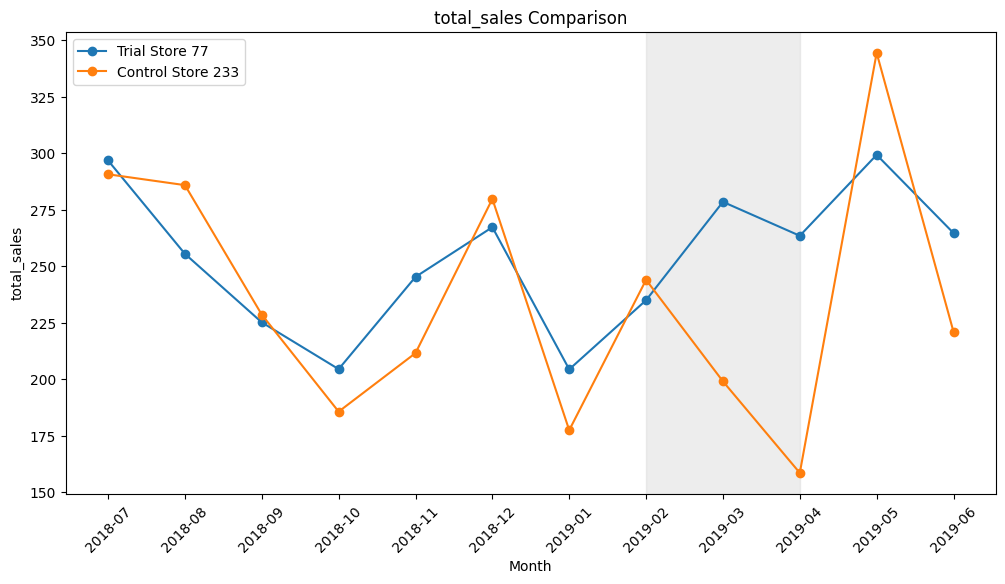

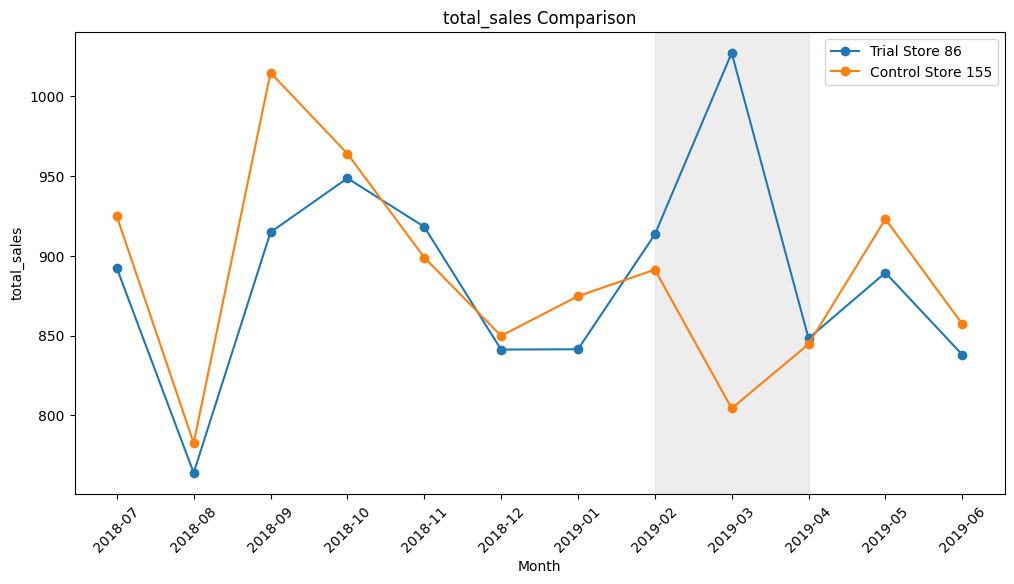

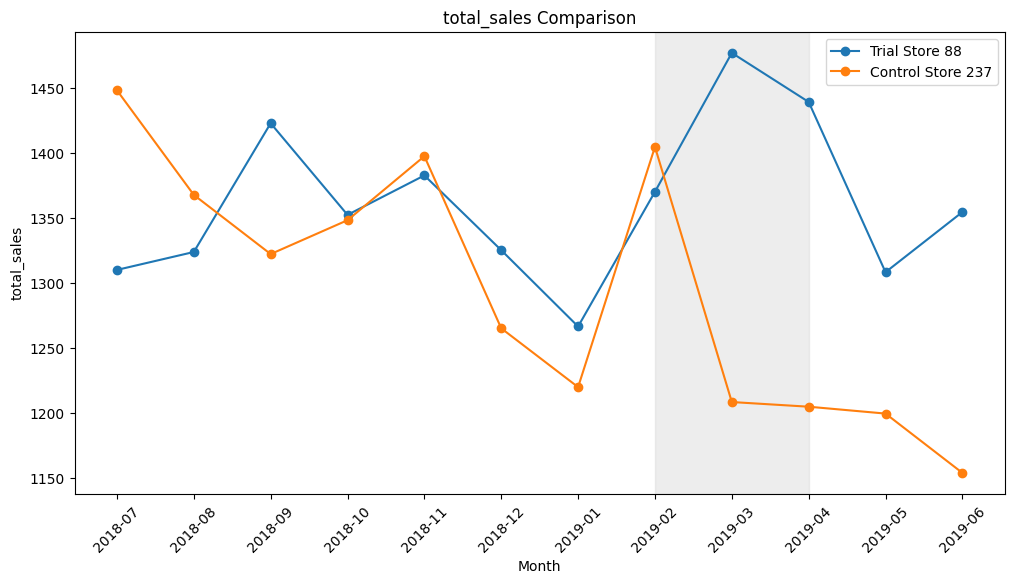

In [28]:
plot_store_comparison(77, 233)
plot_store_comparison(86, 155)
plot_store_comparison(88, 237)

### Additional Store 88 Control Validation

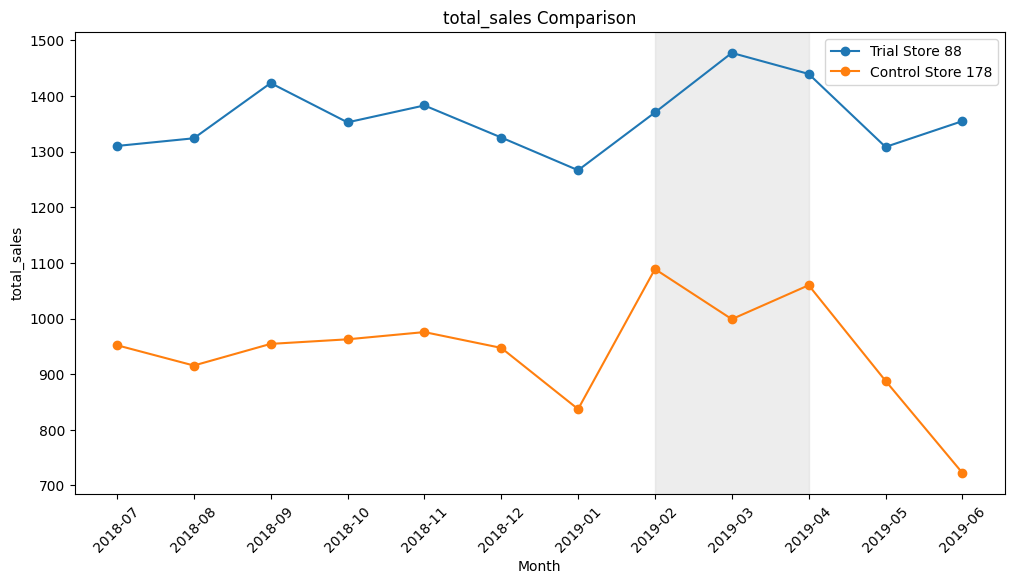

In [29]:
plot_store_comparison(88, 178)

#### Final Control Store Decision

Store 237 was initially selected for Store 88 based on the combined similarity score. However, visual validation showed weaker alignment in monthly sales movement during the pre-trial period.

Additional candidates were reviewed, and Store 178 was selected as the final control store for Store 88 because it showed a more reasonable historical sales pattern for comparison.

The final control stores used for uplift testing are:
- Store 77 → Store 233
- Store 86 → Store 155
- Store 88 → Store 178

## 14. Trial Period Uplift Assessment

The selected control stores were scaled to align with the pre-trial performance of the trial stores.

This section evaluates whether trial stores experienced significantly different sales performance during the trial period from February 2019 to April 2019.

In [30]:
final_control_store_77 = 233
final_control_store_86 = 155
final_control_store_88 = 178

In [31]:
#trial pairs
store_pairs = {
    77: 233,
    86: 155,
    88: 178
}

#### Scaling Control Stores

Control stores may operate at different absolute sales levels compared to trial stores.

To enable fair comparison, control store sales are scaled using the ratio of pre-trial sales between the trial and control stores.

This adjustment ensures that differences observed during the trial period are more likely attributable to the trial layout rather than baseline store size differences.

In [32]:
def calculate_scaling_factor(trial_store, final_control_store):

    trial_sales = pre_trial_data[
        pre_trial_data['STORE_NBR'] == trial_store
    ]['total_sales'].sum()

    control_sales = pre_trial_data[
        pre_trial_data['STORE_NBR'] == final_control_store
    ]['total_sales'].sum()

    scaling_factor = trial_sales / control_sales

    return scaling_factor

In [33]:
# calculating scaling factor
scaling_77 = calculate_scaling_factor(77, 233)
scaling_86 = calculate_scaling_factor(86, 155)
scaling_88 = calculate_scaling_factor(88, 178)

print(scaling_77)
print(scaling_86)
print(scaling_88)

1.023617303289553
0.9700651481287743
1.4338146535258616


In [34]:
def scale_control_store(trial_store, final_control_store, scaling_factor):

    control_data = monthly_store_metrics_complete[
        monthly_store_metrics_complete['STORE_NBR'] == final_control_store
    ].copy()

    control_data['scaled_sales'] = (
        control_data['total_sales'] * scaling_factor
    )

    control_data['trial_store'] = trial_store

    return control_data

In [35]:
scaled_control_77 = scale_control_store(77, 233, scaling_77)
scaled_control_86 = scale_control_store(86, 155, scaling_86)
scaled_control_88 = scale_control_store(88, 178, scaling_88)

#### Comparing Trial Stores Against Scaled Controls

The scaled control stores are compared against trial stores across the full observation period.

The shaded region represents the trial period from February 2019 to April 2019.

If the trial layout had a positive impact, trial store performance should diverge positively from the scaled control store during the trial period.

In [36]:
def plot_scaled_comparison(trial_store, final_control_store, scaled_control_data):

    trial_data = monthly_store_metrics_complete[
        monthly_store_metrics_complete['STORE_NBR'] == trial_store
    ]

    plt.figure(figsize=(12,6))

    # Trial store sales
    plt.plot(
        trial_data['MONTH_ID'].astype(str),
        trial_data['total_sales'],
        marker='o',
        label=f'Trial Store {trial_store}'
    )

    # Scaled control sales
    plt.plot(
        scaled_control_data['MONTH_ID'].astype(str),
        scaled_control_data['scaled_sales'],
        marker='o',
        label=f'Scaled Control Store {final_control_store}'
    )

    # Highlight trial period
    plt.axvspan('2019-02', '2019-04', alpha=0.2)

    plt.title(f'Trial Store {trial_store} vs Scaled Control Store {final_control_store}')
    plt.xlabel('Month')
    plt.ylabel('Total Sales')

    plt.xticks(rotation=45)

    plt.legend()

    plt.show()

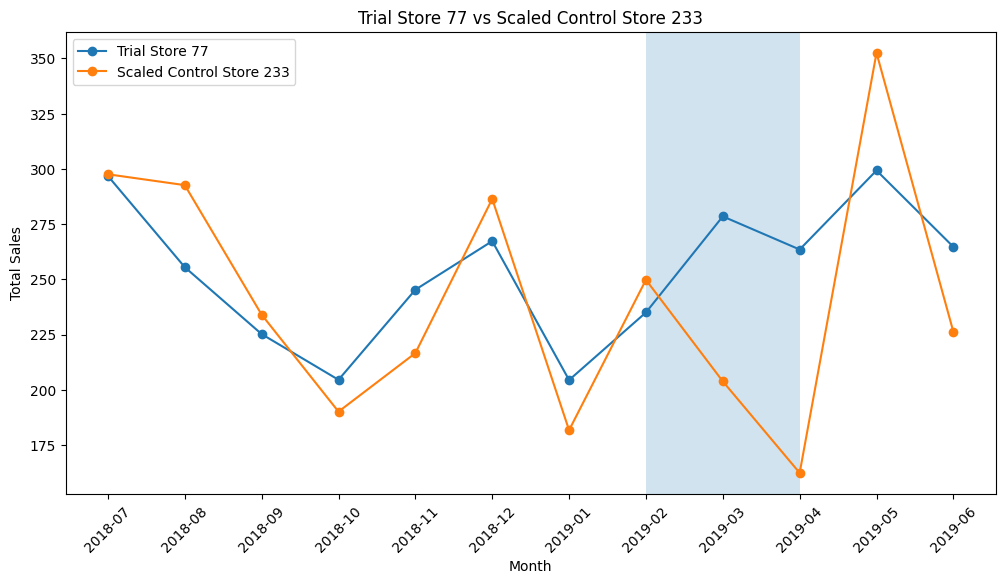

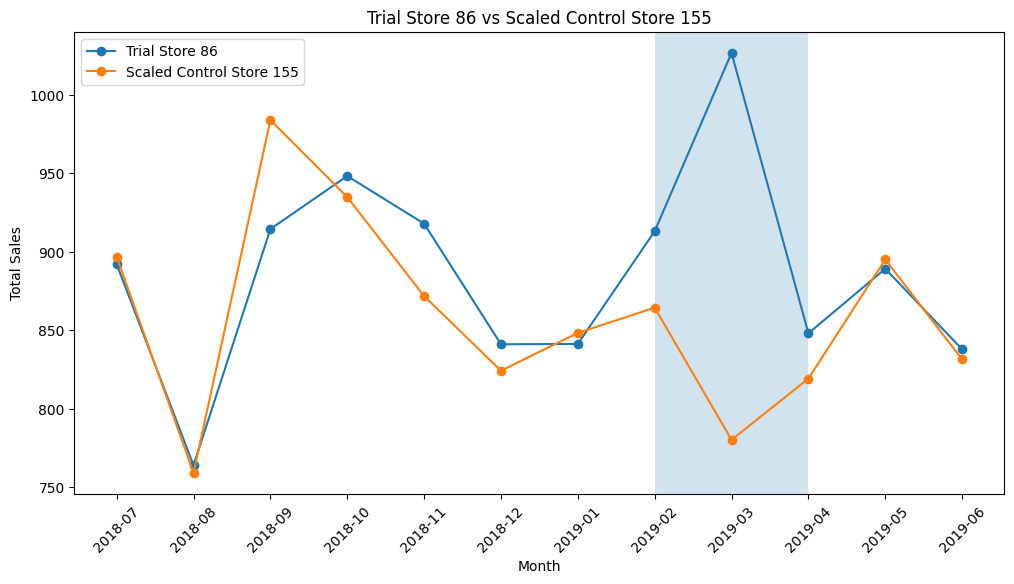

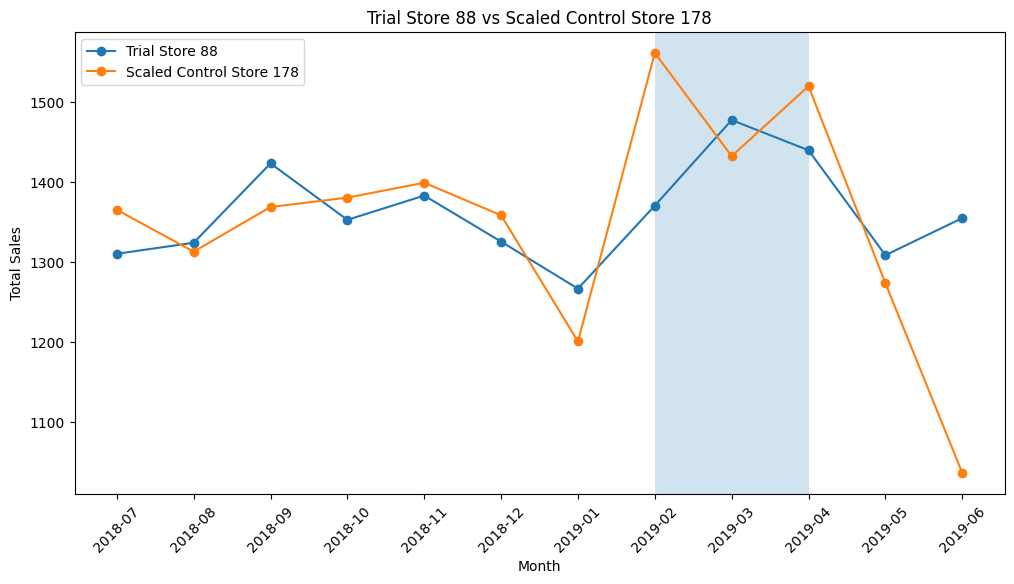

In [37]:
plot_scaled_comparison(77, 233, scaled_control_77)
plot_scaled_comparison(86, 155, scaled_control_86)
plot_scaled_comparison(88, 178, scaled_control_88)

#### Initial Trial Period Observations

After scaling, the control stores provide a more appropriate benchmark for assessing trial performance.

Trial Store 77 shows noticeable sales uplift during the trial period relative to its scaled control store.

Trial Store 86 demonstrates weaker evidence of uplift, with sales movements remaining relatively similar to the control store.

Trial Store 88 does not show clear positive divergence during the trial period, and control matching quality was weaker compared to the other trial stores.

Statistical testing will now be conducted to determine whether observed differences are statistically significant.

## 15. Trial Period Sales Uplift

This section calculates sales uplift during the trial period by comparing actual trial store sales against expected sales from scaled control stores.

In [38]:
def calculate_percentage_uplift(trial_store, scaled_control_data):

    # Trial store data
    trial_data = monthly_store_metrics_complete[
        monthly_store_metrics_complete['STORE_NBR'] == trial_store
    ][['MONTH_ID', 'total_sales']]

    # Merge with scaled control
    comparison = trial_data.merge(
        scaled_control_data[['MONTH_ID', 'scaled_sales']],
        on='MONTH_ID'
    )

    # Calculate uplift %
    comparison['uplift_percentage'] = (
    (comparison['total_sales'] - comparison['scaled_sales'])
    / comparison['scaled_sales']
) * 100

    return comparison

In [39]:
uplift_77 = calculate_percentage_uplift(77, scaled_control_77)
uplift_86 = calculate_percentage_uplift(86, scaled_control_86)
uplift_88 = calculate_percentage_uplift(88, scaled_control_88)

In [40]:
uplift_77.head()

,MONTH_ID,total_sales,scaled_sales,uplift_percentage
0,2018-07,296.8,297.565550,-0.257271
1,2018-08,255.5,292.652187,-12.694997
2,2018-09,225.2,233.998916,-3.760238
3,2018-10,204.5,190.085733,7.583035
4,2018-11,245.3,216.597421,13.251579


In [41]:
trial_uplift_77 = uplift_77[
    (uplift_77['MONTH_ID'] >= '2019-02') &
    (uplift_77['MONTH_ID'] <= '2019-04')
]

trial_uplift_86 = uplift_86[
    (uplift_86['MONTH_ID'] >= '2019-02') &
    (uplift_86['MONTH_ID'] <= '2019-04')
]

trial_uplift_88 = uplift_88[
    (uplift_88['MONTH_ID'] >= '2019-02') &
    (uplift_88['MONTH_ID'] <= '2019-04')
]

In [42]:
print(trial_uplift_77['uplift_percentage'].mean())
print(trial_uplift_86['uplift_percentage'].mean())
print(trial_uplift_88['uplift_percentage'].mean())

31.01646728364261
13.580947268464397
-4.785340331097365


#### Trial Period Uplift Summary

Average sales uplift during the trial period was:

- Store 77: approximately +31.0%
- Store 86: approximately +13.6%
- Store 88: approximately -4.8%

Store 77 shows the strongest positive uplift compared with its scaled control store. Store 86 shows a smaller positive uplift, while Store 88 does not show positive uplift based on the selected control store.

## 16. Statistical Comparison Against Historical Performance
The standard deviation of pre-trial uplift is used as a benchmark for normal variation between each trial store and its scaled control store.

Trial-period uplift is then compared against this historical variation. A larger t-value indicates that observed uplift is less likely to be explained by normal pre-trial fluctuation.

In [43]:
def calculate_significance_table(uplift_data):
    pre_trial = uplift_data[uplift_data['MONTH_ID'] < '2019-02'].copy()
    trial_period = uplift_data[
        (uplift_data['MONTH_ID'] >= '2019-02') &
        (uplift_data['MONTH_ID'] <= '2019-04')
    ].copy()

    std_dev = pre_trial['uplift_percentage'].std()

    trial_period['t_value'] = trial_period['uplift_percentage'] / std_dev

    return trial_period, std_dev

In [44]:
sig_77, std_77 = calculate_significance_table(uplift_77)
sig_86, std_86 = calculate_significance_table(uplift_86)
sig_88, std_88 = calculate_significance_table(uplift_88)

In [45]:
sig_77

,MONTH_ID,total_sales,scaled_sales,uplift_percentage,t_value
7,2019-02,235.0,249.762622,-5.910661,-0.593520
8,2019-03,278.5,203.802205,36.652103,3.680430
9,2019-04,263.5,162.345704,62.307960,6.256669


In [46]:
sig_86

,MONTH_ID,total_sales,scaled_sales,uplift_percentage,t_value
7,2019-02,913.2,864.522060,5.630619,1.494114
8,2019-03,1026.8,780.320405,31.586973,8.381769
9,2019-04,848.2,819.317024,3.525250,0.935444


In [47]:
sig_88

,MONTH_ID,total_sales,scaled_sales,uplift_percentage,t_value
7,2019-02,1370.2,1561.137395,-12.230659,-3.476645
8,2019-03,1477.2,1432.094076,3.149648,0.895308
9,2019-04,1439.4,1519.556770,-5.275010,-1.499456


In [48]:
print("Store 77 pre-trial standard deviation:", std_77)
print("Store 86 pre-trial standard deviation:", std_86)
print("Store 88 pre-trial standard deviation:", std_88)

Store 77 pre-trial standard deviation: 9.958646884078389
Store 86 pre-trial standard deviation: 3.768532790008376
Store 88 pre-trial standard deviation: 3.5179492474944594


## 17. Trial Performance Visualization
The following visualisations compare monthly percentage uplift during the trial period relative to historical variation thresholds.

The dotted horizontal lines represent approximate significance boundaries.

In [49]:
def plot_trial_significance(sig_data, trial_store):

    plt.figure(figsize=(10,5))

    plt.plot(
        sig_data['MONTH_ID'].astype(str),
        sig_data['t_value'],
        marker='o'
    )

    plt.axhline(2, linestyle='--')
    plt.axhline(-2, linestyle='--')

    plt.title(f'Trial Store {trial_store} Statistical Significance')
    plt.xlabel('Month')
    plt.ylabel('t-value')

    plt.xticks(rotation=45)
    plt.savefig(
    f'{trial_store}_significance.png',
    dpi=300,
    bbox_inches='tight'
)

    plt.show()

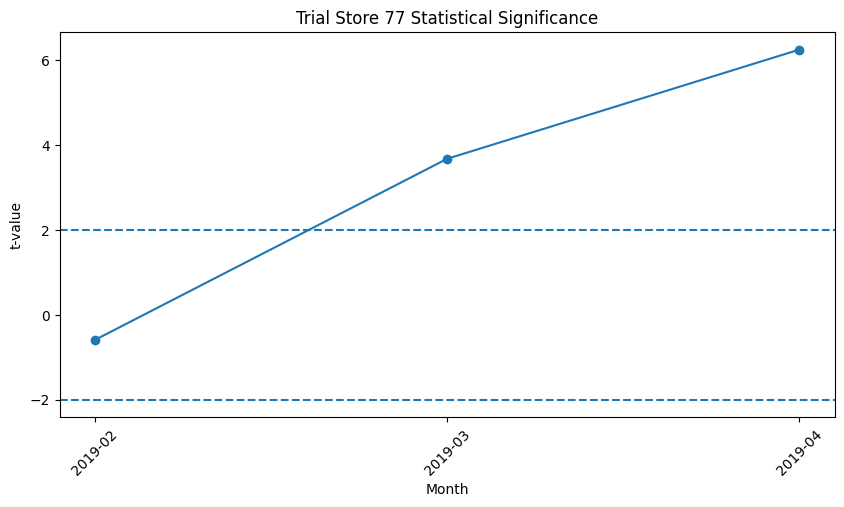

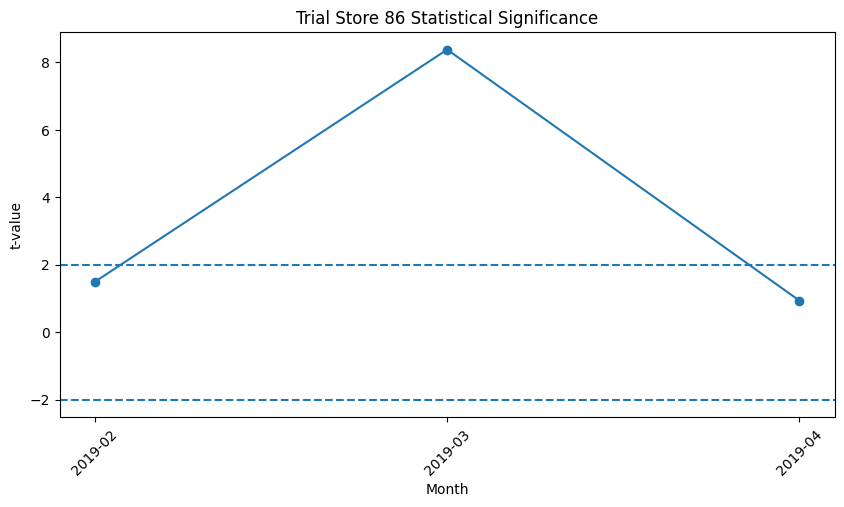

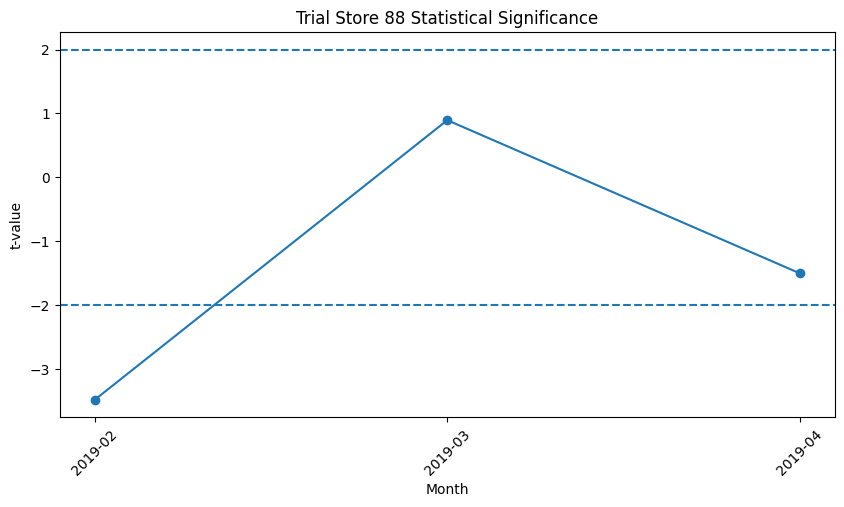

In [50]:
plot_trial_significance(sig_77, 77)
plot_trial_significance(sig_86, 86)
plot_trial_significance(sig_88, 88)

#### Statistical Significance Results

A t-value greater than 2 indicates that trial-period uplift exceeded normal historical variation and may therefore be considered statistically significant.

Key findings:

- Store 77 demonstrated statistically significant uplift during March and April 2019.
- Store 86 showed statistically significant uplift only during March 2019, indicating weaker evidence of sustained trial impact.
- Store 88 showed a statistically significant sales decline relative to control in February 2019, suggesting the new layout may have initially disrupted customer behaviour.
- The March 2019 uplift for Store 86 was exceptionally strong (t=8.4) and warrants further investigation to confirm it reflects genuine trial impact rather than a data anomaly.

These results suggest the trial layout was most successful in Store 77.

## 18. Customer Driver Analysis

To understand what contributed to trial performance, customer counts and transactions per customer were reviewed during the trial period.

This helps determine whether sales uplift was driven by more customers visiting the store or by existing customers purchasing more frequently.

In [56]:
driver_summary = monthly_store_metrics_complete[
    monthly_store_metrics_complete['STORE_NBR'].isin([77, 86, 88, 233, 155, 178])
]
# Pre-trial averages for same stores
driver_summary_pretrial = driver_summary[
    driver_summary['MONTH_ID'] < '2019-02'
]

driver_summary_trial = driver_summary[
    (driver_summary['MONTH_ID'] >= '2019-02') &
    (driver_summary['MONTH_ID'] <= '2019-04')
]

driver_summary_trial.groupby('STORE_NBR')[[
    'unique_customers',
    'transactions_per_customer'
]].mean()

,unique_customers,transactions_per_customer
STORE_NBR,,
77,47.333333,1.040426
86,109.000000,1.235704
88,128.666667,1.253563
155,96.000000,1.261077
178,112.666667,1.291494
233,38.333333,1.045370


### Customer Driver Interpretation

Store 77’s uplift appears to be sales-led rather than strongly driven by a large increase in customer count, as its customer base remained relatively small compared with the control group.

Store 86 had higher customer activity during the trial period, which supports the positive March uplift result.

Store 88 had strong customer numbers but did not show positive sales uplift, suggesting that customer volume alone did not translate into stronger sales performance.

## 19. Trial Outcome Summary

The trial assessment combined correlation analysis, scaled control benchmarking, uplift measurement and statistical significance testing to evaluate the effectiveness of the new store layouts.

Key findings:

- Store 77 demonstrated the strongest and most consistent positive uplift during the trial period.
- Store 86 showed moderate evidence of improvement, although uplift was not consistently significant across all trial months.
- Store 88 did not show statistically significant positive uplift and therefore does not provide strong evidence that the new layout improved sales.

Overall, the trial results suggest that the layout implementation was most successful in Store 77.

In [52]:
final_results = pd.DataFrame({
    'Trial Store': [77, 86, 88],
    'Control Store': [233, 155, 178],
    'Average Trial Uplift (%)': [
        trial_uplift_77['uplift_percentage'].mean(),
        trial_uplift_86['uplift_percentage'].mean(),
        trial_uplift_88['uplift_percentage'].mean()
    ]
})

final_results

,Trial Store,Control Store,Average Trial Uplift (%)
0,77,233,31.016467
1,86,155,13.580947
2,88,178,-4.785340


## 20. Final Recommendations

Based on the trial analysis:

- The layout trial for Store 77 should be considered successful and may warrant rollout consideration to similar stores.
- Store 86 showed some positive signs of improvement, however additional testing may be beneficial before wider implementation.
- Store 88 showed a net negative average sales effect during the trial and should not be considered for wider rollout of this layout format.

Further investigation into store-specific customer behaviour, demographics and operational differences may help explain variation in trial performance across stores.